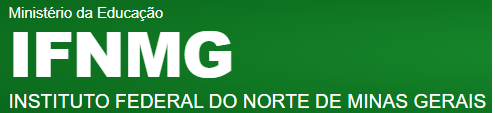

#Disciplina: Projeto Integrador I

####Professor: Ms. Nestor Madureira
####Aluna: Eng. Isabela Gomes da Costa



# Tema: Profile of the typical customer for each treadmill product offered by CardioGood Fitness ( Perfil típico de consumidor para cada esteira ofertada pela CardioGood Fitness).


**Conjunto dos dados:**

**Contexto**

Trabalho na área de desenho mecânico, em uma empresa que fabrica esteiras e outros produtos fitness. Compreender o perfil de consumidor para cada produto fornecido pela empresa pode me auxiliar no desenvolvimento do design de novos produtos, direcionando certos aspectos funcionais de acordo com a demanda de clientes mais bem demarcados. Essa foi a motivação por tras da escolha desse dataset em questão, para a resolução da Atividade Prática da disciplina Projeto Integrador I.

------------------------------------------------------------------------

**Conteúdo**

O arquivo CardioGoodFitness.csv possui informações referentes a consumidores da empresa fictícia CardioGood Fitness. No material de estudo, informa-se que os dados foram recolhidos por 3 meses, pela equipe de pesquisa do departamento de Marketing, com o intuito de indentificar o perfil dos consumidores para 3 modelos de esteiras, totalizando 180 clientes específicos. Abaixo, detalha-se as variáveis do problema.  

**Product/Produto - "Alvo" (Variável categórica nominal):**

Indica o produto comprado, os modelos possíveis são: TM195, TM498, ou TM798.

**Age/Idade - (Variável Discreta):**

A OMS indica que o uso de esteiras para crianças (a partir de 9 anos), seja apenas recreativo. Para adultos este equipamento é amplamento recomendado, pelo seus benefícios relacionados a saúde em geral, em especial para o sistema cardiovascular. Para os idosos, segue a recomendação, com a observação de acompanhamento médico, decorrente a condições específicas de saúde, como problemas de coluna e articulações. No banco de dados temos idades de 18 a 50 anos, ou seja, todos são classificados como adultos.

**Gender/Gênero - (Variável categórica nominal):**

Tem-se a divisão entre o gênero feminino e masculino, não há especificação referente a cisgeneridade ou transexualidade.

**Education/Educação - (Variável Discreta):**

Esta variável define a quantidade de anos de estudo da pessoa em questão. Como os dados são baseados em norte-americanos, define-se que o ensino básico é dividido em 12 séries/anos, ou seja, qualquer quantidade acima dessa já indica algum grau de educação superior/tecnólogo.

**MaritalStatus/Status de Relacionamento - (Variável categórica nominal):**

Status de relacionamento, dividido em solteiro(a) ou em relacionamento.

**Usage/Uso - (Variável Discreta):**

Número médio de vezes por semana que planeja-se usar o equipamento.

**Fitness - (Variável Discreta):**

Autoavaliação física do comprador, em uma escala de 1 a 5, onde 1 é uma condição física ruim e 5 é uma condição física excelente.

**Income/Renda - (Variável Contínua):**

Valor anual da renda familiar, em dólar americano. Como o banco de dados é mais antigo, segue a classificação média dos valores para o ano de 2019:
Classe Baixa: Inferior a 40.100;
Classe Média: Entre 40.100 e 120.400;
Classe Alta: Superior a 120.400.

**Miles/Milhas - (Variável Discreta):**

Número médio de milhas que o cliente espera caminhar/correr a cada semana. As recomendações gerais de distância (em milhas) por semana são: Iniciante - 5 a 10 milhas (aproximadamente 8 a 16 km); Intermediário - 15 a 30 milhas (aproximadamente 24 a 48 km); Avançado - 35 a 50+ milhas (aproximadamente 56 a 80+ km). Treinos estruturados com foco em alta performance e provas longas.

------------------------------------------------------------------------

**Fundamentação**

O mercado global fitness cresce a um ritmo anual de 8%. Este crescimento acelerado se da por as discussões latentes da sociedade, como as referentes a longevidade, bem-estar e saúde mental. O Brasil se destaca como um dos maiores mercados de fitness do mundo, possuindo mais de 32 mil academias ativas. Cerca de 50% dos brasileiros já praticam atividades físicas regularmente, diminuindo os níveis históricos de sedentarismo. Uma das vertentes que surgiram nos últimos anos foi a integração da tecnologia nesta área, como no caso do uso de dados de saúde, aplicativos de treino e gamificação para medir a evolução do aluno. Com este embasamento, aplica-se o estudo presente.

Fonte: https://www.kaggle.com/datasets/saurav9786/cardiogoodfitness/data


# Carregamento dos Dados

In [4]:
#Importação das bibliotecas
import seaborn as sb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score, cohen_kappa_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

In [5]:
#Abrindo o arquivo
!unzip /content/CardioGoodFitness.zip

Archive:  /content/CardioGoodFitness.zip
  inflating: CardioGoodFitness.csv   


In [6]:
#Importação do arquivo CSV
df = pd.read_csv('/content/CardioGoodFitness.csv')

In [7]:
#Visualização inicial dos registros
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


In [8]:
#Quantidade de linhas e colunas do dataset
print(df.shape)

(180, 9)


In [9]:
#Verificação dos tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [10]:
#Verificando se há dados duplicados
df.duplicated().sum()

np.int64(0)

# Análise Descritiva


In [11]:
#Estatísticas básicas;
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [12]:
target = df.columns[0]
target

'Product'

In [13]:
print(df.columns)

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')


In [14]:
#Frequência das classes
# Variável alvo # ajuste se necessário
print(df[target].value_counts())

Product
TM195    80
TM498    60
TM798    40
Name: count, dtype: int64


In [15]:
# Proporção de amostras de cada tipo em %
print(df[target].value_counts(normalize=True).round(2))

Product
TM195    0.44
TM498    0.33
TM798    0.22
Name: proportion, dtype: float64


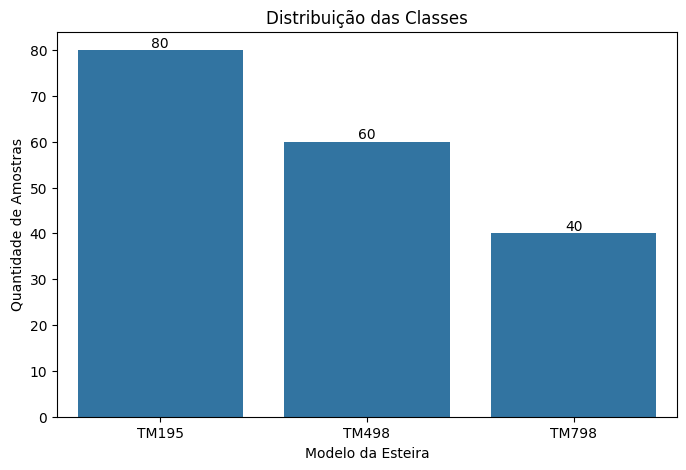

In [16]:
#Demonstração visual em gráfico de barras da contagem de amostras de cada produto

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Product')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribuição das Classes')
plt.xlabel('Modelo da Esteira')
plt.ylabel('Quantidade de Amostras')

plt.show()

Conforme demonstrado acima, o modelo TM195 é o mais vendido, representando aproximadamente 44% das amostras, seguido pelo TM498 (33%) e TM798 (22%).

##Análise Univariada

In [17]:
#Análise inicial das variáveis
#Numéricas: Age, Education, Usage, Fitness, Income, Miles;

<Axes: xlabel='Age', ylabel='Count'>

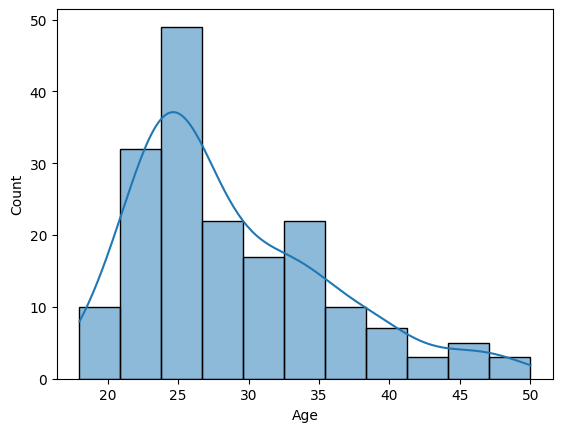

In [18]:
sns.histplot(df['Age'], kde=True)

<Axes: xlabel='Age'>

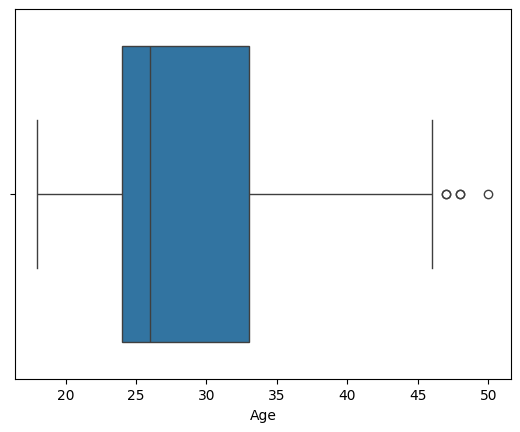

In [19]:
sns.boxplot(x=df['Age'])

Os valores de idade estão mais concentrados próximo de 25 anos.

<Axes: xlabel='Education', ylabel='Count'>

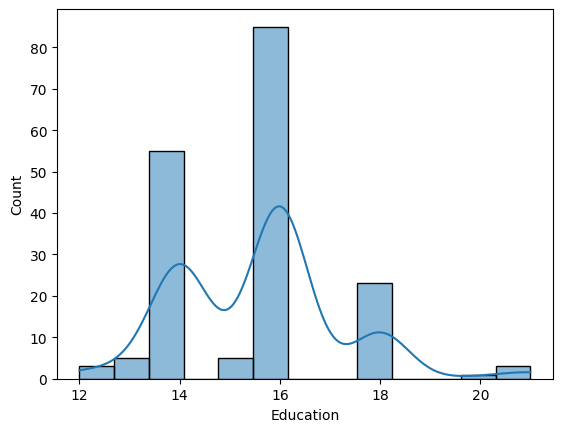

In [20]:
sns.histplot(df['Education'], kde=True)

<Axes: xlabel='Education'>

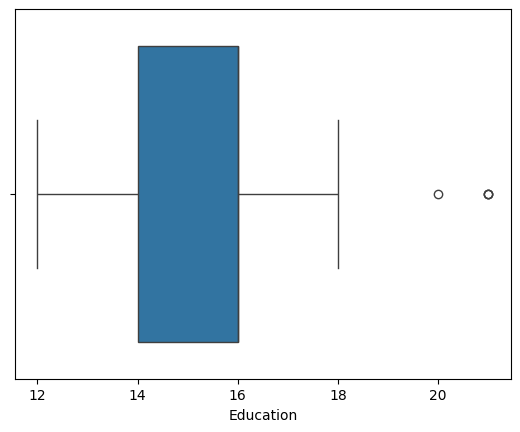

In [21]:
sns.boxplot(x=df['Education'])

Os picos de anos de educação são, por ordem descrescente: 16, 14 e 18.

<Axes: xlabel='Usage', ylabel='Count'>

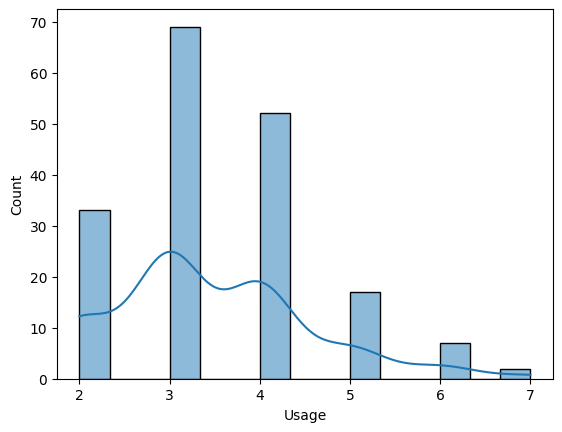

In [22]:
sns.histplot(df['Usage'], kde=True)

<Axes: xlabel='Usage'>

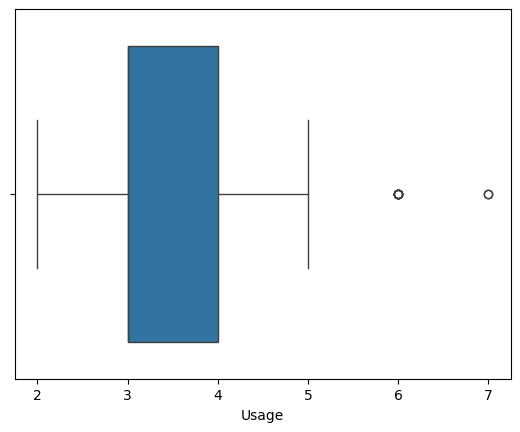

In [23]:
sns.boxplot(x=df['Usage'])

Os dados demonstram que a maioria dos clientes indica que usarão o equipamento de 3 a 4 vezes na semana.

<Axes: xlabel='Fitness', ylabel='Count'>

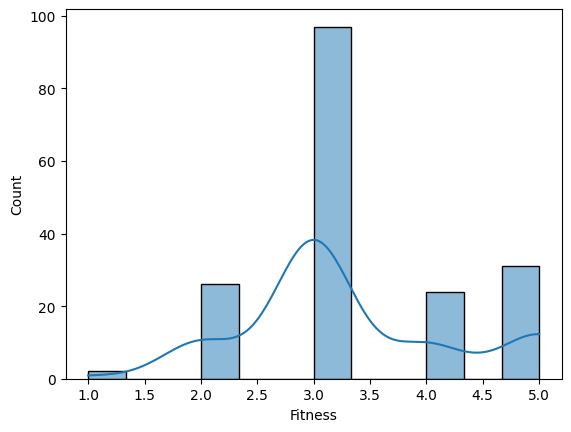

In [24]:
sns.histplot(df['Fitness'], kde=True)

<Axes: xlabel='Fitness'>

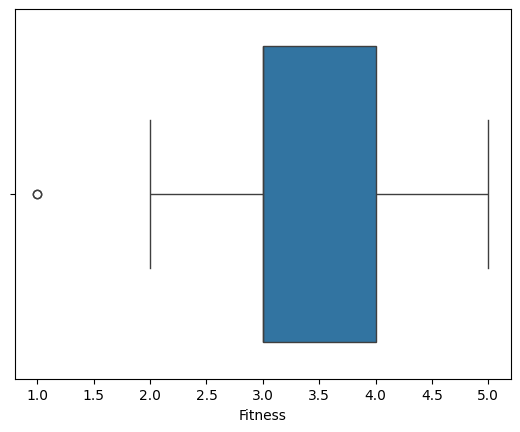

In [25]:
sns.boxplot(x=df['Fitness'])

O nível físico da maior parte dos clientes se concentra acima de 3.

<Axes: xlabel='Income', ylabel='Count'>

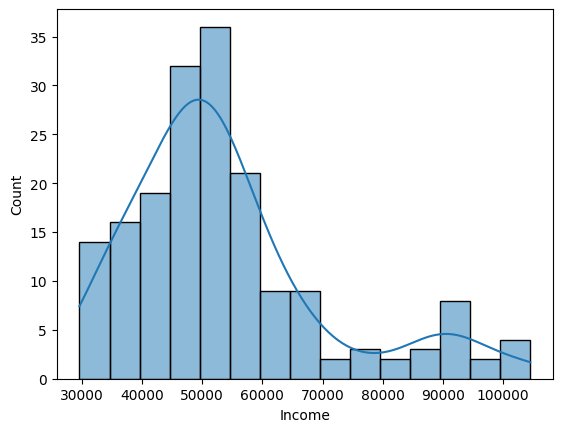

In [26]:
sns.histplot(df['Income'], kde=True)

<Axes: xlabel='Income'>

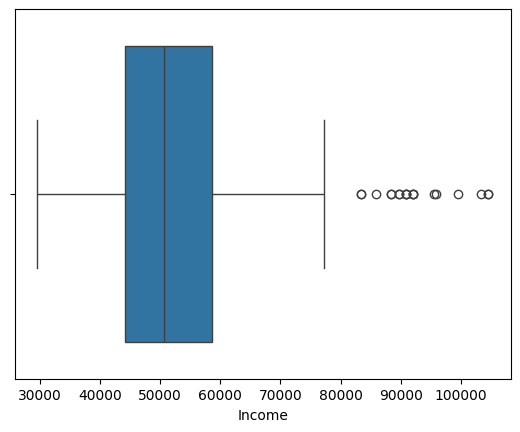

In [27]:
sns.boxplot(x=df['Income'])

As amostram indicam uma concentração de renda a cerca de $50.000.

<Axes: xlabel='Miles', ylabel='Count'>

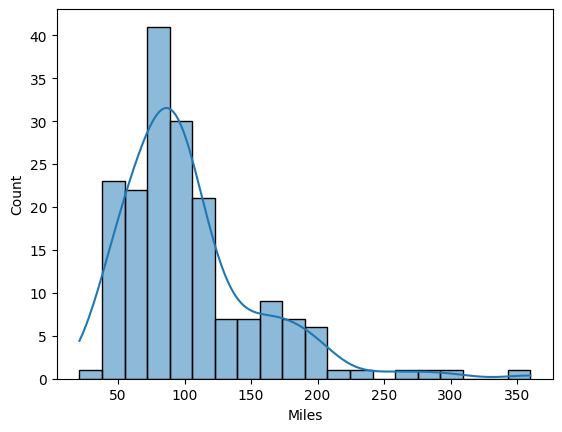

In [28]:
sns.histplot(df['Miles'], kde=True)

<Axes: xlabel='Miles'>

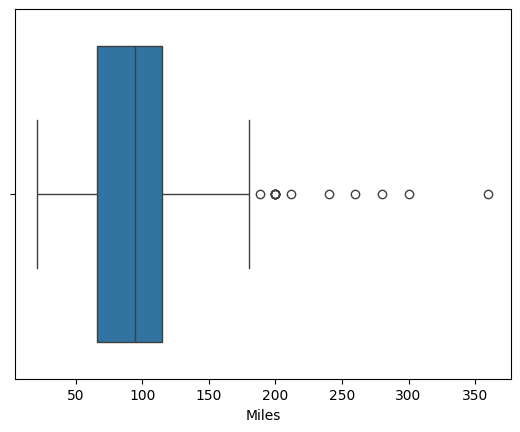

In [29]:
sns.boxplot(x=df['Miles'])

Conforme determinado na introdução do trabalho, vê-se que a maior porção dos compradores são pessoas que já estão em um nível avançado na caminhada/corrida, pois os valores se concentram a cerca de 90 milhas por semana.

In [30]:
#Análise inicial das variáveis
#Categóricas: Product (frequência verificada nos passos anteriores), Gender, MaritalStatus.

<Axes: xlabel='Gender', ylabel='count'>

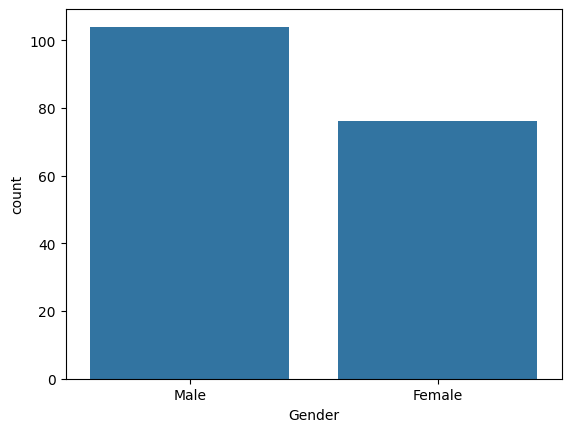

In [31]:
sns.countplot(data=df, x='Gender')

<Axes: xlabel='MaritalStatus', ylabel='count'>

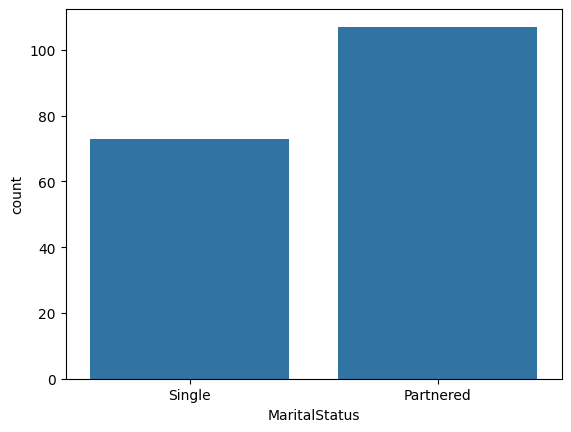

In [32]:
sns.countplot(data=df, x='MaritalStatus')

Há mais compradores homens, e mais compradores comprometidos.

##Análise Multivariada

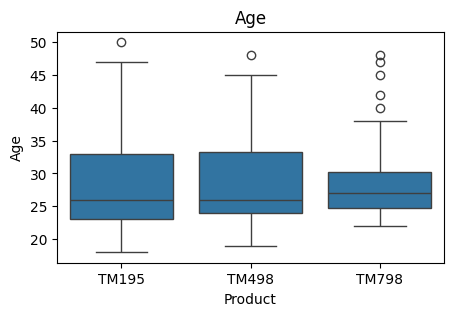

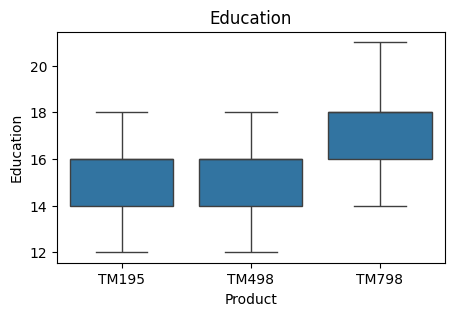

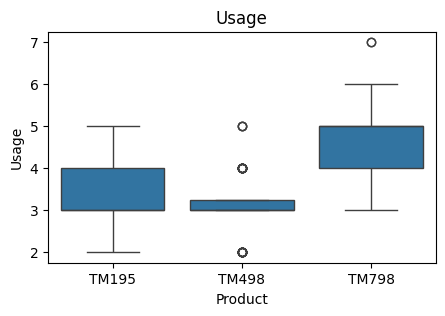

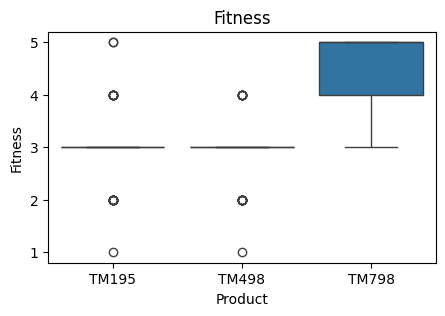

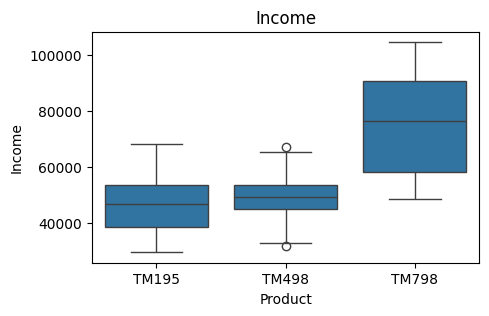

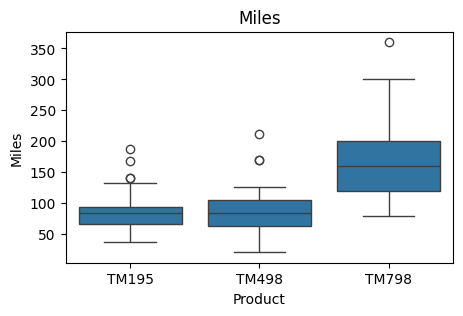

In [33]:
#Relação com target
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    if col != target:
        plt.figure(figsize=(5,3))
        sns.boxplot(x=target, y=col, data=df)
        plt.title(col)
        plt.show()

A idade dos compradores apresenta distribuição semelhante entre os três modelos de esteira. O modelo TM798 distoa um pouco, possuindo mais compradores acima de 40 anos.


Compradores com maior nível educacional, maior uso, melhor condicionamento físico, maior renda, e que percorrem maiores distâncias preferem o modelo TM798.

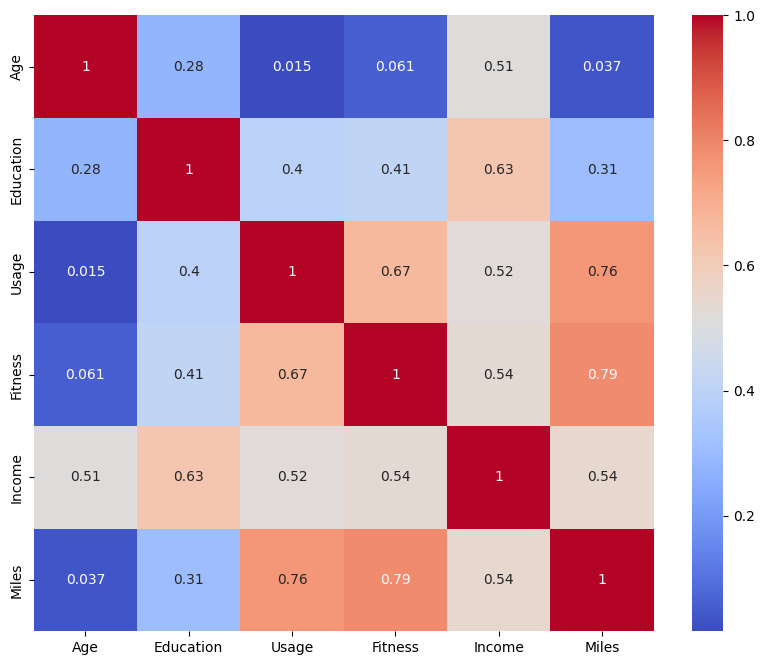

In [34]:
# Correlação
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True ,cmap='coolwarm')
plt.show()

A matriz de correlação foi utilizada para identificar relações lineares entre as variáveis numéricas. Observou-se correlação positiva entre Fitness, Usage e Miles, indicando que usuários com maior condicionamento físico tendem a utilizar mais a esteira e percorrer maiores distâncias.

# Análise de Dispersão dos dados

<Axes: xlabel='Income', ylabel='Miles'>

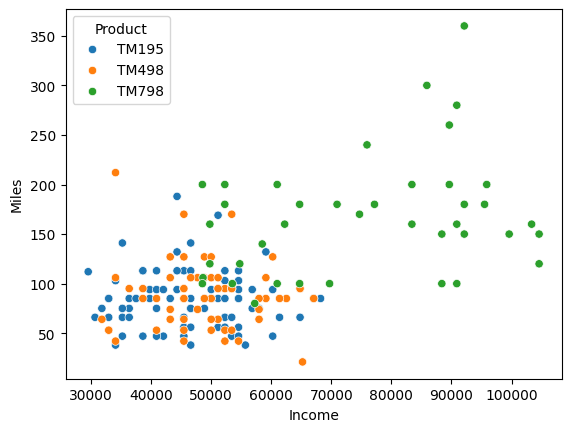

In [35]:
sns.scatterplot(
    data=df,
    x='Income',
    y='Miles',
    hue='Product'
)

Compradores com maior renda tendem a percorrem maiores distâncias.

# Conclusões da Análise Exploratória

*   Há certo desbalanceamento entre as variáveis categóricas, mas não é algo extremo, então ainda possibilita o treinamento inicial do modelo de classificação sem necessidade balanceamento;
*   Os desvios padrões estão condizentes;
*   Um ponto de destaque são as escalas presentes no dataset, implicando a necessidade de normalização dos dados numéricos em passos adiante;

Relações observadas:

*   Há mais compradores com cerca de 25 anos do que 35 anos e acima;
*   A maioria dos compradores continuaram seus estudos além da escola básica;
*   Pessoas com melhor condicionamento físico buscam adquitir equipamentos fitness com maior frequência do que as pessoas com condicionamento físico pior;
*   Os compradores são, em sua maioria, de classe média;
*   Os clientes que adquirem os produtos já caminham/correm em nível avançado;
*   Compradores com maior renda tendem a percorrem maiores distâncias.

Outliers:
*   Em relação aos outliers observados nos boxplots, entende-se que fazem parte dos dados e não são anomalias. Por exemplo, tanto na variável de renda, quanto na de milhas, há uma quantidade de outliers considerável, mas é esperado que um pequeno grupo faça parte da classe alta, e que um pequeno grupo seja de corredores profissionais, o que justifica a maior quantidade de milhas que estes clientes pretendem percorrer.









O perfil dos compradores dos itens TM195 e TM498 são bem similares, o item TM798 é o que mais distoa. Assim, pode-se concluir que, compradores com maior nível educacional, maior uso, melhor condicionamento físico, maior renda, e que percorrem maiores distâncias preferem o modelo TM798.

# Tratamento dos Dados

*   Não há valores ausentes, nem duplicados;
*   Em relação aos outliers, são considerados parte do dataset, não anomalias;
*   Sobre os desbalanceamentos, serão mantidos a princípio, pois, não são críticos. Caso o modelo se provar ruim, reavaliarei esta decisão.


# Preparação dos Dados


In [36]:
#Separa as variáveis de entrada (features) da variável alvo (target)
X = df.drop(columns=['Product'])   # remove a coluna alvo
y = df['Product']                  # seleciona apenas a variável alvo

In [37]:
#Transformação das variáveis categóricas em numéricas
X = pd.get_dummies(X, drop_first=True)

#Codificação do target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [38]:
#Importa a função responsável por dividir os dados em treino e teste
from sklearn.model_selection import train_test_split

#Realiza a divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(

    X,                  # Conjunto de variáveis independentes (features)
    y,                  # Variável alvo (target)
    test_size=0.2,      # Reserva 20% dos dados para teste e 80% para treino
    random_state=42,    # Define uma semente para reproduzir sempre a mesma divisão
    stratify=y          # Mantém a proporção das classes no treino e no teste
)

In [39]:
#Importa o escalonador robusto
from sklearn.preprocessing import RobustScaler

#Cria o objeto de escalonamento
#O RobustScaler utiliza mediana e intervalo interquartil (IQR)
#sendo menos sensível a outliers
scaler = RobustScaler()

#Ajusta o escalonador no conjunto de treino
#e transforma os dados
X_train_scaled = scaler.fit_transform(X_train)

#Aplica no conjunto de teste os mesmos parâmetros
#aprendidos no conjunto de treino
X_test_scaled = scaler.transform(X_test)

## **Observação Importante**


O método fit_transform() é aplicado no conjunto de treino porque ele possui duas funções:

fit(): calcula a mediana de cada atributo;
transform(): substitui os valores ausentes por essas medianas.

Já no conjunto de teste, utilizamos apenas transform(), garantindo que os dados de teste sejam tratados com os mesmos parâmetros aprendidos no treinamento.

Esse procedimento evita vazamento de dados (data leakage), preservando a integridade da avaliação do modelo.

In [40]:
# Converte os dados escalonados do conjunto de treino
# novamente para DataFrame, preservando colunas e índices originais
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)
# Converte os dados escalonados do conjunto de teste
# novamente para DataFrame, preservando a mesma estrutura
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [41]:
X_train_scaled.head()

,Age,Education,Usage,Fitness,Income,Miles,Gender_Male,MaritalStatus_Single
6,-0.606061,-1.0,0.0,0.0,-1.071518,-0.463415,-1.0,0.0
12,-0.484848,0.0,1.0,0.0,-0.992147,-0.463415,-1.0,1.0
54,0.484848,-1.0,0.0,0.0,0.277801,-0.219512,0.0,1.0
141,-0.484848,0.0,0.0,2.0,0.292112,0.634146,0.0,1.0
57,0.727273,-1.0,0.0,1.0,-0.277801,0.463415,-1.0,1.0


In [42]:
X_test_scaled.head()

,Age,Education,Usage,Fitness,Income,Miles,Gender_Male,MaritalStatus_Single
103,-0.121212,-1.0,1.0,0.0,-0.357173,1.853659,0.0,0.0
108,0.000000,0.0,1.0,0.0,-0.357173,-0.219512,-1.0,0.0
178,2.545455,1.0,1.0,2.0,3.768551,0.634146,0.0,0.0
74,1.818182,0.0,1.0,0.0,0.277801,0.219512,0.0,0.0
52,0.363636,0.0,1.0,0.0,-0.039686,0.000000,-1.0,0.0


# Construção do Modelo de Classificação - Gradient Boosting


In [43]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

y_pred = gb.predict(X_test_scaled)

In [44]:
# Extrai o nível de importância de cada variável
importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': gb.feature_importances_
})

importances = importances.sort_values(
    by='Importance',
    ascending=False
)

importances


,Feature,Importance
5,Miles,0.438995
3,Fitness,0.239687
4,Income,0.126237
0,Age,0.073613
1,Education,0.061583
2,Usage,0.049692
7,MaritalStatus_Single,0.006160
6,Gender_Male,0.004033


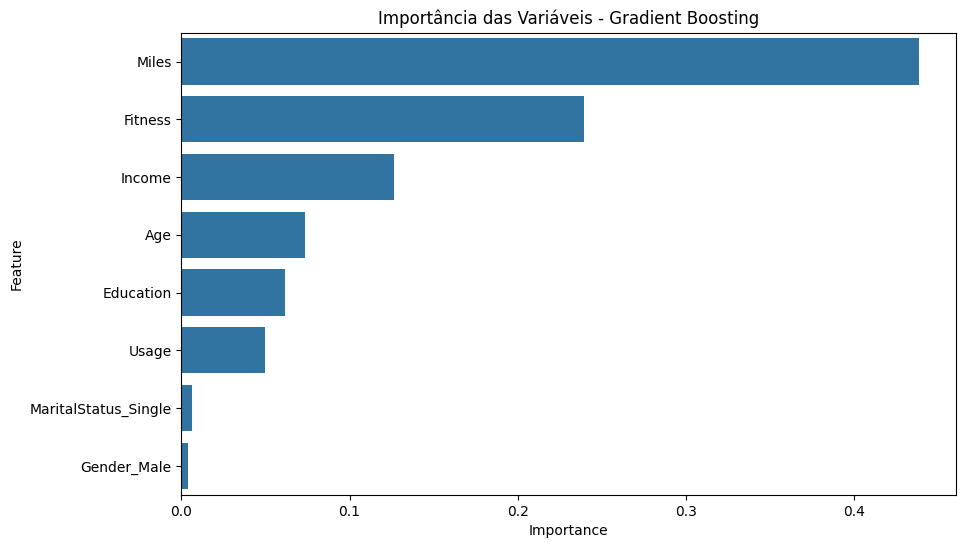

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importances,
    x='Importance',
    y='Feature'
)

plt.title('Importância das Variáveis - Gradient Boosting')
plt.show()

A variável mais relevante é a distância que o cliente pretende percrrer por semana, depois vem a variável Fitness (nível físivo),	e depois, Income (renda). A importância encontrada pelo modelo está de acordo com aos padrões observados durante a análise exploratória dos dados.
Apesar de Gender e MaritalStatus apresentarem baixa importância, optou-se por manter todas as variáveis no modelo. Pois, têm-se apenas oito atributos, a remoção dessas variáveis poderia resultar em perda de informações potencialmente úteis para a classificação.

# Avaliação do Modelo - Gradient Boosting

In [46]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.75      0.50      0.60        12
           2       0.80      1.00      0.89         8

    accuracy                           0.75        36
   macro avg       0.76      0.77      0.75        36
weighted avg       0.75      0.75      0.74        36

[[13  2  1]
 [ 5  6  1]
 [ 0  0  8]]


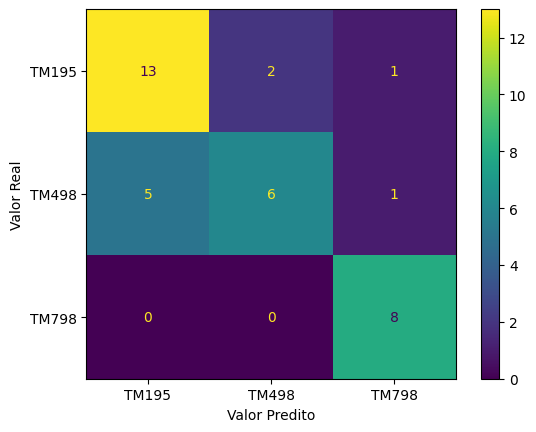

In [47]:
from sklearn import metrics
import matplotlib.pyplot as plt

classes = ['TM195', 'TM498', 'TM798']

Matriz_1 = metrics.confusion_matrix(y_test, y_pred)
M1 = metrics.ConfusionMatrixDisplay(
    confusion_matrix=Matriz_1,
    display_labels=classes
)
M1.plot()
plt.xlabel("Valor Predito")
plt.ylabel("Valor Real")
plt.show()

O modelo Gradient Boosting atingiu acurácia de 75%. A análise da matriz de confusão mostrou excelente desempenho na identificação dos compradores do produto TM798, com taxa de reconhecimento de 100%.

As maiores dificuldades ocorreram na distinção entre os produtos TM195 e TM498. Esse comportamento era esperado, pois a análise exploratória indicou que os perfis dos compradores desses modelos apresentam características semelhantes, enquanto os compradores do TM798 possuem um perfil mais distinto.


## Otimização de hiperparametros Gradient Boosting

In [50]:
!pip install optuna

import optuna

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

def objective(trial):

    modelo = GradientBoostingClassifier(

        n_estimators=trial.suggest_int(
            "n_estimators",
            50,
            300
        ),

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        max_depth=trial.suggest_int(
            "max_depth",
            2,
            8
        ),

        min_samples_split=trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        min_samples_leaf=trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        subsample=trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        random_state=42
    )

    modelo.fit(X_train_scaled, y_train)

    y_pred = modelo.predict(X_test_scaled)

    score = accuracy_score(y_test, y_pred)

    return score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.6 MB/s eta 0:00:00


In [51]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=50)

print("Melhores parâmetros:")
print(study.best_params)

print("Melhor acurácia:")
print(study.best_value)

[I 2026-06-26 09:09:33,471] A new study created in memory with name: no-name-fae26d90-f6a9-4910-a301-dbf2801b66c5
[I 2026-06-26 09:09:34,725] Trial 0 finished with value: 0.6944444444444444 and parameters: {'n_estimators': 85, 'learning_rate': 0.06550194891476724, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 1, 'subsample': 0.9748694410311426}. Best is trial 0 with value: 0.6944444444444444.
[I 2026-06-26 09:09:36,015] Trial 1 finished with value: 0.7222222222222222 and parameters: {'n_estimators': 204, 'learning_rate': 0.2766382394653472, 'max_depth': 5, 'min_samples_split': 17, 'min_samples_leaf': 5, 'subsample': 0.7081045065048016}. Best is trial 1 with value: 0.7222222222222222.
[I 2026-06-26 09:09:38,627] Trial 2 finished with value: 0.7222222222222222 and parameters: {'n_estimators': 233, 'learning_rate': 0.06779289350337331, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 4, 'subsample': 0.8640884920765488}. Best is trial 1 with value: 0.72222222222222

Melhores parâmetros:
{'n_estimators': 254, 'learning_rate': 0.09852535560499404, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 1, 'subsample': 0.6616837471954782}
Melhor acurácia:
0.75


In [53]:
gb_final = GradientBoostingClassifier(
    **study.best_params,
    random_state=42
)

gb_final.fit(X_train_scaled, y_train)

y_pred = gb_final.predict(X_test_scaled)

In [54]:
gb_final.fit(X_train_scaled, y_train)

GradientBoostingClassifier(learning_rate=0.09852535560499404, max_depth=4,
                           min_samples_split=11, n_estimators=254,
                           random_state=42, subsample=0.6616837471954782)

In [55]:
y_pred = gb_final.predict(X_test_scaled)

# Avaliação do modelo final - GB

In [56]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.4f}')

Accuracy: 0.7500


In [57]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['TM195','TM498','TM798']
))

              precision    recall  f1-score   support

       TM195       0.68      0.81      0.74        16
       TM498       0.75      0.50      0.60        12
       TM798       0.89      1.00      0.94         8

    accuracy                           0.75        36
   macro avg       0.77      0.77      0.76        36
weighted avg       0.75      0.75      0.74        36



In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13  2  1]
 [ 6  6  0]
 [ 0  0  8]]


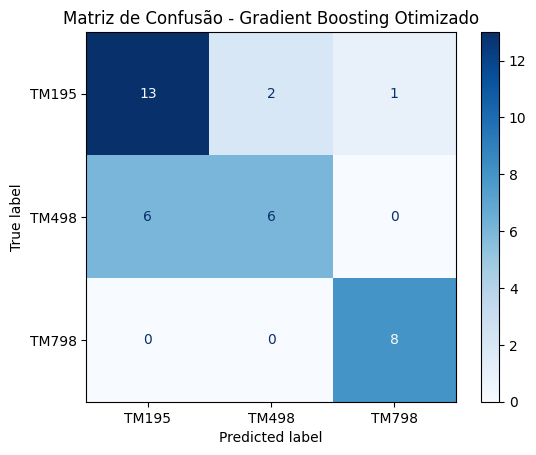

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['TM195','TM498','TM798']
)

disp.plot(
    cmap='Blues',
    values_format='d'
)

plt.title('Matriz de Confusão - Gradient Boosting Otimizado')

plt.show()

No meu caso, a otimização não trouxe muita vantagem vantagem. Nas métricas, teve pontos que até piorou levemente, e na na matriz de confusão teve a melhora de uma previsão para o modelo TM498.

# Validação cruzada do modelo final - GB

In [60]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    gb_final,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Média:", scores.mean())
print("Desvio:", scores.std())

[0.86206897 0.62068966 0.72413793 0.65517241 0.82142857]
Média: 0.7366995073891625
Desvio: 0.09290776213687343


O modelo apresentou acurácia média de 73,7% na validação cruzada, indicando de média/alta capacidade de generalização.

In [64]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def visualizar_kfold(modelo, X_treino, y_treino, perc_treino, k):

    train_sizes, train_scores, valid_scores = learning_curve(
        estimator=modelo,
        X=X_treino,
        y=y_treino,
        train_sizes=np.array([perc_treino]),
        cv=k,
        scoring="accuracy",
        shuffle=True,
        random_state=42
    )

    train_scores = train_scores.flatten()
    valid_scores = valid_scores.flatten()

    print(f"Acurácia média no treino: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"Acurácia média na validação: {valid_scores.mean():.4f} ± {valid_scores.std():.4f}")

    fig, ax = plt.subplots(1,2, figsize=(12,5))

    # Accuracy em cada Fold
    ax[0].plot(
        range(1,k+1),
        train_scores,
        marker='o',
        linewidth=2,
        label='Treino'
    )

    ax[0].plot(
        range(1,k+1),
        valid_scores,
        marker='o',
        linewidth=2,
        label='Validação'
    )

    ax[0].set_xlabel("Fold")
    ax[0].set_ylabel("Accuracy")
    ax[0].set_title("Accuracy por Fold")
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    # Histograma das validações
    ax[1].hist(
        valid_scores,
        bins=5
    )

    ax[1].set_title("Distribuição da Accuracy")
    ax[1].set_xlabel("Accuracy")
    ax[1].set_ylabel("Frequência")

    plt.tight_layout()
    plt.show()

Acurácia média no treino: 1.0000 ± 0.0000
Acurácia média na validação: 0.7505 ± 0.0787


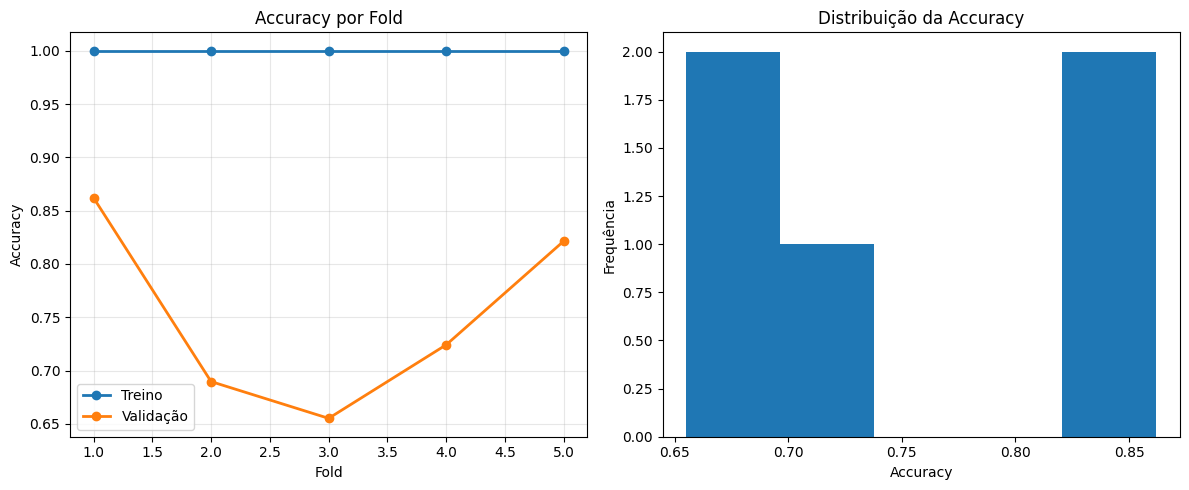

In [66]:
visualizar_kfold(
    modelo=gb_final,
    X_treino=X_train_scaled,
    y_treino=y_train,
    perc_treino=1.0,
    k=5
)

Ocurreu um overfitting no treino, e o modelo não se saiu tão bem na validação. Em relação a acurácia, está entre mediana e boa, pois tem índices acima de 65%, variando até 85%.

# Construção do Modelo de Classificação - Decision Tree (pra efeitos de comparação)

In [67]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Avaliação do Modelo - Decision Tree

Acurácia: 0.8056

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.79      0.94      0.86        16
           1       1.00      0.50      0.67        12
           2       0.73      1.00      0.84         8

    accuracy                           0.81        36
   macro avg       0.84      0.81      0.79        36
weighted avg       0.85      0.81      0.79        36



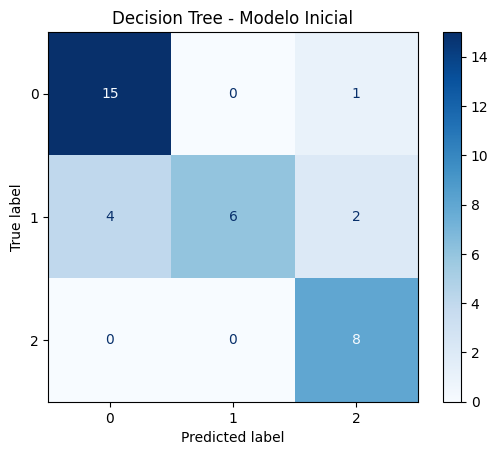

In [68]:
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Acurácia: {acc_dt:.4f}\n")

print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt.classes_
)

disp.plot(cmap="Blues")
plt.title("Decision Tree - Modelo Inicial")
plt.show()


O modelo Decision Tree atingiu acurácia de 81%. A análise da matriz de confusão mostrou excelente desempenho na identificação dos compradores do produto TM798, com taxa de reconhecimento de 100%, assim como no Gradient Booting.

As maiores dificuldades ocorreram na distinção entre os produtos TM195 e TM498, nesse modelo melhorou um pouco, mas ainda segue a mesma situação.

# Otimização do Modelo - Decision Tree

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_dt.best_params_)

print("\nMelhor score:")
print(grid_dt.best_score_)

Melhores parâmetros:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}

Melhor score:
0.7445812807881774


In [71]:
#Treinando o melhor modelo
best_dt = grid_dt.best_estimator_

best_dt.fit(X_train, y_train)

y_pred_best = best_dt.predict(X_test)

# Avaliação do modelo otimizado - DT

Acurácia: 0.7778

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.78      0.88      0.82        16
           1       0.86      0.50      0.63        12
           2       0.73      1.00      0.84         8

    accuracy                           0.78        36
   macro avg       0.79      0.79      0.77        36
weighted avg       0.79      0.78      0.76        36



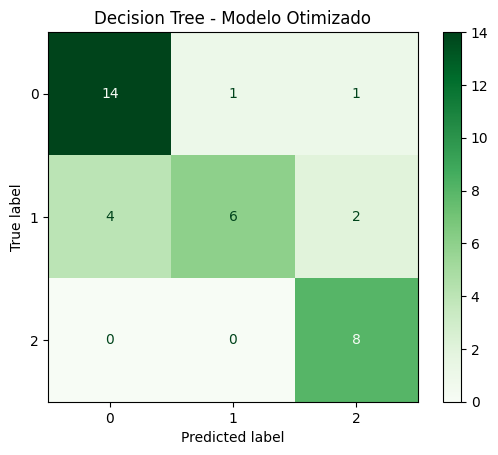

In [72]:
acc_best = accuracy_score(y_test, y_pred_best)

print(f"Acurácia: {acc_best:.4f}\n")

print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_dt.classes_
)

disp.plot(cmap="Greens")
plt.title("Decision Tree - Modelo Otimizado")
plt.show()

# Validação com SVC - DT

In [73]:
from sklearn.svm import SVC

svc = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    random_state=42
)

svc.fit(X_train_scaled, y_train)

y_pred_svc = svc.predict(X_test_scaled)

# Avaliação do modelo final - DT

Acurácia SVC: 0.6667

              precision    recall  f1-score   support

           0       0.58      0.94      0.71        16
           1       1.00      0.08      0.15        12
           2       0.89      1.00      0.94         8

    accuracy                           0.67        36
   macro avg       0.82      0.67      0.60        36
weighted avg       0.79      0.67      0.58        36



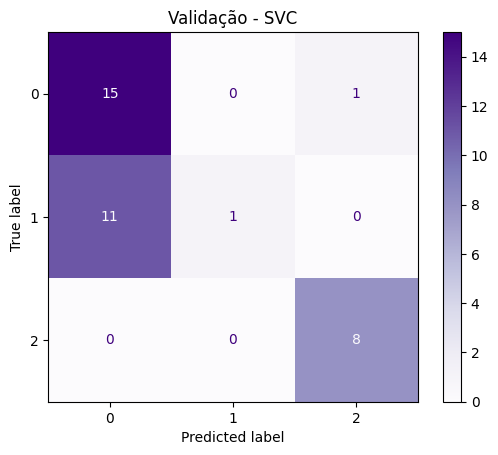

In [74]:
acc_svc = accuracy_score(y_test, y_pred_svc)

print(f"Acurácia SVC: {acc_svc:.4f}\n")

print(classification_report(y_test, y_pred_svc))

cm = confusion_matrix(y_test, y_pred_svc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svc.classes_
)

disp.plot(cmap="Purples")
plt.title("Validação - SVC")
plt.show()

In [77]:
#Curva de Aprendizado
def visualizar_curva_aprendizado(modelo, X_treino, y_treino,
                                 perc_treino=0.8, k=5):

    train_sizes, train_scores, valid_scores = learning_curve(
        estimator=modelo,
        X=X_treino,
        y=y_treino,
        train_sizes=[perc_treino],
        cv=k,
        scoring="accuracy",
        shuffle=True,
        random_state=42,
        n_jobs=-1
    )

    train_scores = train_scores.ravel()
    valid_scores = valid_scores.ravel()

    print(f"Acurácia média no treino: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"Acurácia média na validação: {valid_scores.mean():.4f} ± {valid_scores.std():.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    # Accuracy por Fold
    ax[0].plot(
        range(1, k+1),
        train_scores,
        marker='o',
        linewidth=2,
        label='Treino'
    )

    ax[0].plot(
        range(1, k+1),
        valid_scores,
        marker='o',
        linewidth=2,
        label='Validação'
    )

    ax[0].set_title("Accuracy por Fold")
    ax[0].set_xlabel("Fold")
    ax[0].set_ylabel("Accuracy")
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    # Histograma das acurácias
    ax[1].hist(valid_scores, bins=5)

    ax[1].set_title("Distribuição da Accuracy")
    ax[1].set_xlabel("Accuracy")
    ax[1].set_ylabel("Frequência")

    plt.tight_layout()
    plt.show()

Acurácia média no treino: 0.9413 ± 0.0202
Acurácia média na validação: 0.6680 ± 0.1171


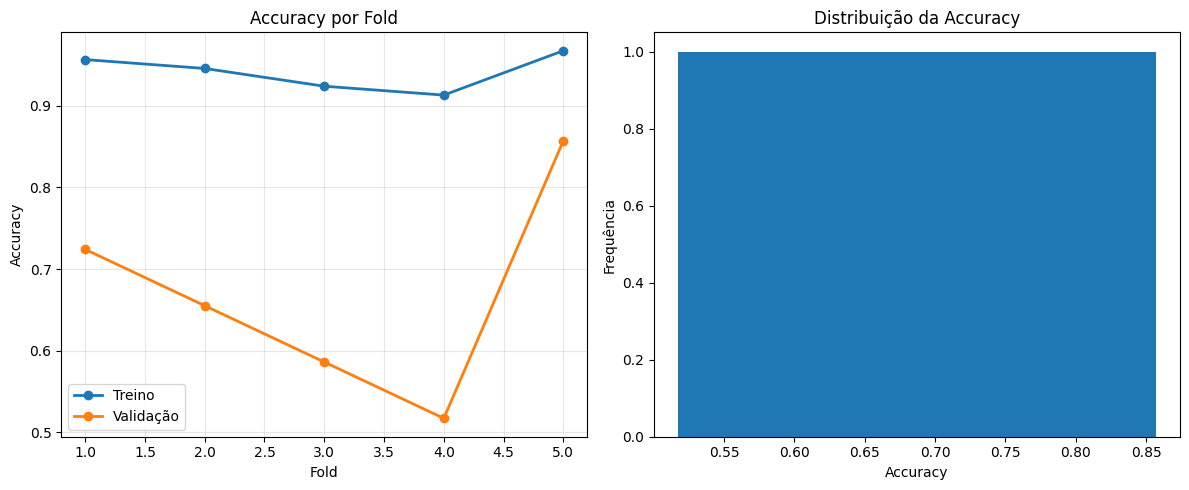

In [78]:
visualizar_curva_aprendizado(
    modelo=best_dt,
    X_treino=X_train,
    y_treino=y_train,
    perc_treino=0.8,
    k=5
)

O modelo Decision Tree se saiu bem melhor, pois não teve overfitting, mesmo a taxa de acurácia sendo um pouco mais baixa. No geral, o pior ponto foi na avaliação, e posso relacionar isso ao modelo TM498, pois as métricas para ele foram péssimas.

# Conclusão


*   Os dados do dataset são de boa qualidade, isso pode ser notado por não haver nenhum dado nulo ou duplicado. Além disso, mesmo com o leve desbalanceamento, onde havia mais dados com compra dos itens TM195 e TM498, o modelo não foi negativamente afetado por isso, pois, mesmo com menos dados, o item TM798 foi o mais bem classificado.
*   Escolhi primeiramente o modelo Gradient Boosting, pois o caso possui poucos atributos, e, relativamente, poucas amostras. No entanto, comparando com o Desicion Tree, o Gradient ficou um pouco menos adequado. Decision Tree atingiu acurácia de 81%, já o Gradient Boosting atingiu acurácia de 75%, todas as outras métricas vistas seguiram esta mesma tendência (antes da otimização e da validação).
*   A etapa de otimização dos modelos, não resultou em melhora significativa no desempenho do modelo. A acurácia do modelo Decision Tree passou de aproximadamente 81% para 78%, indicando que o modelo inicial já estava ajustado em relaçãoa ao conjunto de dados.
*   Como forma de validação, para o melhor modelos (D.T.) foi utilizado um modelo SVC. O desempenho, nesse caso, foi inferior, com acurácia de aproximadamente 67%, os resultados mostraram que a separação entre as classes TM195 e TM498 continua sendo o principal desafio do problema, enquanto a classe TM798 manteve o índice de acerto alto.
*   A análise da curva de aprendizado da Decision Tree indicou a presença de overfitting, uma vez que a acurácia média no treinamento foi de aproximadamente 94%, enquanto na validação ficou em torno de 67%. Isso confirma que o modelo aprende muito bem (até demais) os dados de treinamento, mas possui dificuldade em manter o mesmo desempenho em novos dados, indicando que um conjunto de dados maior poderia melhorar sua capacidade de generalização.
*   As etapas mais dificultosas foram a contextualização, o tempo pra analisar as variáveis, pesquisar sobre as mesmas, para desenvolver o ambasamento necessário para a execução da atividade. Outro ponto foi a análise do comportamento dos dados, fazer a análise de cada atributo e do seu comportamento, e imputar as conclusões iniciais a partir disso. Ademais, foi trabalhoso, no entanto, o exemplo disposto pelo professor determinou o meu bom resultado no passo a passo.
*   Para trabalhos futuros, pretendo priorizar datasets com maior quantidade de amostras para um resultado mais complexo. Além disso, com novos estudos, posso aplicar outros modelos, outras métricas de otimização e validação.



